<a href="https://colab.research.google.com/github/LauraRii/projeto-final-cdd-2026-/blob/main/projetofinalcdd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto: Análise de Saúde Mental em Gamers

In [101]:
import pandas as pd # --> biblioteca para manipulação de dataframes
import numpy as np # --> cálculos matemáticos

df = pd.read_csv('Gaming and Mental Health.csv') # --> abre o arquivo bruto

print("Colunas do Dataset:")
print(df.columns.tolist()) # --> mostra o nome das colunas

df.head() # --> mostra as 5 primeiras linhas


Colunas do Dataset:
['record_id', 'age', 'gender', 'daily_gaming_hours', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance', 'grades_gpa', 'work_productivity_score', 'mood_state', 'mood_swing_frequency', 'withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems', 'eye_strain', 'back_neck_pain', 'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score', 'face_to_face_social_hours_weekly', 'monthly_game_spending_usd', 'years_gaming', 'gaming_addiction_risk_level']


,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [102]:
print(" Informações do Dataset ")
df.info() # --> exibe um resumo do df (nome das colunas, tipos de dados, quantos valores não nulos existem)

print("\n Valores Faltantes ")
print(df.isnull().sum()[df.isnull().sum() > 0]) # --> primeiro conta os valores nulos por coluna, e depois exibe apenas as colunas que
# possuem pelo menos 1 valor nulo [parte dentro do colchetes é a condição]).

 Informações do Dataset 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-nul

In [103]:
df.fillna(0, inplace=True) # --> substitui todos os valores NaN (nulos) do df por 0, o inplace=True faz a alteração direto na variável

print(f"Total de valores nulos após a limpeza: {df.isnull().sum().sum()}") # --> soma a quantidade de valores nulos após a limpeza

df[['grades_gpa', 'work_productivity_score']].head() # --> mostra as 5 primeiras linhas das colunas que tinham valores nulos

Total de valores nulos após a limpeza: 0


,grades_gpa,work_productivity_score
0,1.25,0.0
1,3.75,2.0
2,0.00,9.0
3,1.62,2.0
4,2.44,0.0


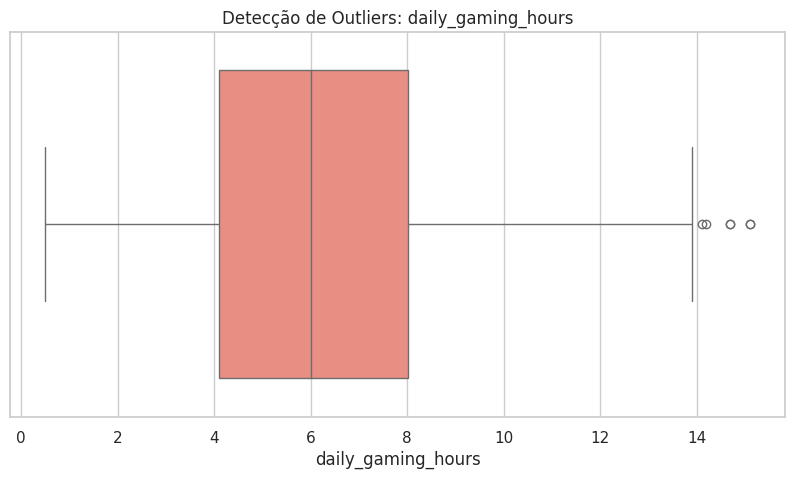

Limite Superior (Corte): 13.91 horas
Quantidade de outliers detectados: 6


In [104]:
import matplotlib.pyplot as plt # --> biblioteca de visualização (gráficos)
import seaborn as sns # --> biblioteca de visualização (gráficos mais bonitos)

# --> removi outliers na coluna de horas jogadas por dia
coluna_alvo = 'daily_gaming_hours' # --> seleciona a coluna a ser analisada

if coluna_alvo in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[coluna_alvo], color='salmon') # --> gerando um boxplot para visualização dos outliers
    plt.title(f'Detecção de Outliers: {coluna_alvo}')
    plt.show()

# --> escolhi o primeiro e o terceiro quartil para analisar mais o "meio" do df
    Q1 = df[coluna_alvo].quantile(0.25) # --> calcula o primeiro quartil
    Q3 = df[coluna_alvo].quantile(0.75) # --> calcula o terceiro quartil
    IQR = Q3 - Q1 # --> calcula a amplitude interquartílica

# --> aqui são definidas as fronteiras. qualquer valor fora delas é considerado um outlier.
# o 1.5 é a parte além do limite onde se checa se há outliers. usei 1.5 porque é o padrão.
    limite_inferior = Q1 - 1.5 * IQR # --> negativo porque é abaixo dos 25%
    limite_superior = Q3 + 1.5 * IQR # --> poaitivo porque é acima dos 75%

    outliers = df[(df[coluna_alvo] < limite_inferior) | (df[coluna_alvo] > limite_superior)] # --> o | quer dizer OU
    print(f"Limite Superior (Corte): {limite_superior:.2f} horas")
    print(f"Quantidade de outliers detectados: {len(outliers)}")
else:
    print(f"Erro: A coluna '{coluna_alvo}' não foi encontrada.")

In [105]:
df_limpo = df[df['daily_gaming_hours'] <= limite_superior].copy() # --> cria um novo df sem os outliers detectados
df_descritivo = df_limpo
print(f"Linhas antes: {len(df)}")
print(f"Linhas após removeção os outliers: {len(df_limpo)}")

Linhas antes: 1000
Linhas após removeção os outliers: 994


In [106]:
# como as máquinas não entendem texto e alguns dados são palavras, tive que transformá-los em números usando o labelencoder
# da biblioteca sklearn, que transforma texto em números

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() # --> instanciando o labelencoder

# aplicando o labelencoder nas colunas de gênero e estado de humor
df['gender_n'] = le.fit_transform(df['gender'])
df['mood_state_n'] = le.fit_transform(df['mood_state'])

# eu fiz um mapeamento da coluna de risco. não usei o labelencoder porque tem uma hierarquia entre as palavras que ele não pegaria
risco_map = {'Low': 0, 'Moderate': 1, 'High': 2, 'Severe': 3}
df['risk_level_n'] = df['gaming_addiction_risk_level'].map(risco_map) # --> aqui eu falei para o pandas percorrer a coluna de nível de risco
# e mudar os dados que ele achar de acordo com o mapa de risco

df[['gender', 'gender_n', 'gaming_addiction_risk_level', 'risk_level_n']].head() # --> mostra as cinco primeiras linhas depois da conversão

,gender,gender_n,gaming_addiction_risk_level,risk_level_n
0,Male,1,Severe,3
1,Male,1,Low,0
2,Male,1,Severe,3
3,Female,0,High,2
4,Male,1,Moderate,1


In [107]:
# como técninca de normalização de dados, eu escolhi a de máximo e mínimo porque esses valores são conhecidos e todos os outliers foram
# neutralizados anteriormente. ele vai colocar todos os números em um intervalo de [0,1]

from sklearn.preprocessing import MinMaxScaler # --> importando o escalonador

scaler = MinMaxScaler() # --> criando o objeto que vai calcular os mínimos e máximos

# selecionando as colunas para escalonar
cols_para_escalar = ['age', 'daily_gaming_hours', 'sleep_hours', 'weight_change_kg', 'monthly_game_spending_usd', 'years_gaming']
df_limpo[cols_para_escalar] = scaler.fit_transform(df_limpo[cols_para_escalar]) # --> descobre qual é o menor valor e o maior valor de cada
# coluna e aplica a fórmula em cada linha

df_limpo[cols_para_escalar].head() # mostrando as cinco primeiras linhas de cada coluna após o escalonamento

,age,daily_gaming_hours,sleep_hours,weight_change_kg,monthly_game_spending_usd,years_gaming
0,0.181818,0.791045,0.116667,0.764045,0.768476,0.105263
1,0.363636,0.186567,0.700000,0.044944,0.093235,0.000000
2,0.454545,0.529851,0.233333,0.202247,0.201755,0.263158
3,0.318182,0.500000,0.350000,0.022472,0.103171,0.315789
4,0.227273,0.470149,0.066667,0.056180,0.065048,0.000000


In [108]:
# aqui eu peguei as colunas que tem valores como true e false para escaloná-las também. true vira 1 e false vira 0

cols_bool = ['withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems',
             'eye_strain', 'back_neck_pain'] # --> todas as colunas que tem valores como True ou False

for col in cols_bool:
    df_limpo[col] = df_limpo[col].astype(int) # --> é o astype que converte True em 1 e False em 0

# aqui eu fiz o mesmo mapeamento que eu fiz na coluna de risco para essas outras três colunas
mapa_sono = {'Very Poor': 0, 'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
mapa_freq = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Daily': 4}
mapa_performance = {'Poor': 0, 'Below Average': 1, 'Average': 2, 'Good': 3, 'Excellent': 4}

if 'sleep_quality' in df_limpo.columns:
    df_limpo['sleep_quality_n'] = df_limpo['sleep_quality'].map(mapa_sono)
if 'sleep_disruption_frequency' in df_limpo.columns:
    df_limpo['sleep_disruption_n'] = df_limpo['sleep_disruption_frequency'].map(mapa_freq)
if 'academic_work_performance' in df_limpo.columns:
    df_limpo['academic_performance_n'] = df_limpo['academic_work_performance'].map(mapa_performance)

# aplicando conversões para df_descritivo
if 'sleep_quality' in df_descritivo.columns:
    df_descritivo['sleep_quality_n'] = df_descritivo['sleep_quality'].map(mapa_sono)
if 'sleep_disruption_frequency' in df_descritivo.columns:
    df_descritivo['sleep_disruption_n'] = df_descritivo['sleep_disruption_frequency'].map(mapa_freq)
if 'academic_work_performance' in df_descritivo.columns:
    df_descritivo['academic_performance_n'] = df_descritivo['academic_work_performance'].map(mapa_performance)

# o inplace é para substituir as colunas antigas por essas novas colunas com os dados convertidos
cols_to_drop = ['sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance']

df_limpo.drop(columns=[col for col in cols_to_drop if col in df_limpo.columns], inplace=True)

df_descritivo.drop(columns=[col for col in cols_to_drop if col in df_descritivo.columns], inplace=True)

# garante que as colunas 'sleep_quality_n' e 'academic_performance_n' existam antes de tentar exibi-las
cols_to_display = cols_bool[:] # shallow copy
if 'sleep_quality_n' in df_limpo.columns:
    cols_to_display.append('sleep_quality_n')
if 'academic_performance_n' in df_limpo.columns:
    cols_to_display.append('academic_performance_n')

df_limpo[cols_to_display].head() # --> mostra as cinco primeiras linhas das colunas convertidas

,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,eye_strain,back_neck_pain,sleep_quality_n,academic_performance_n
0,1,0,1,1,0,0.0,1.0
1,0,0,0,0,0,2.0,3.0
2,1,1,1,0,1,2.0,0.0
3,1,1,0,1,1,2.0,0.0
4,1,0,0,0,0,1.0,2.0


In [109]:
# aqui eu decidi não só substituir as colunas antigas como também deletá-las, pra não haver confusão entre colunas e pra não ocupar mais memória

cols_para_remover = ['record_id', 'gaming_addiction_risk_level', 'primary_game', 'game_genre', 'gaming_platform', 'mood_swing_frequency']

df_final = df_limpo.drop(columns=cols_para_remover)

print(f"Colunas restantes: {len(df_final.columns)}")

Colunas restantes: 21


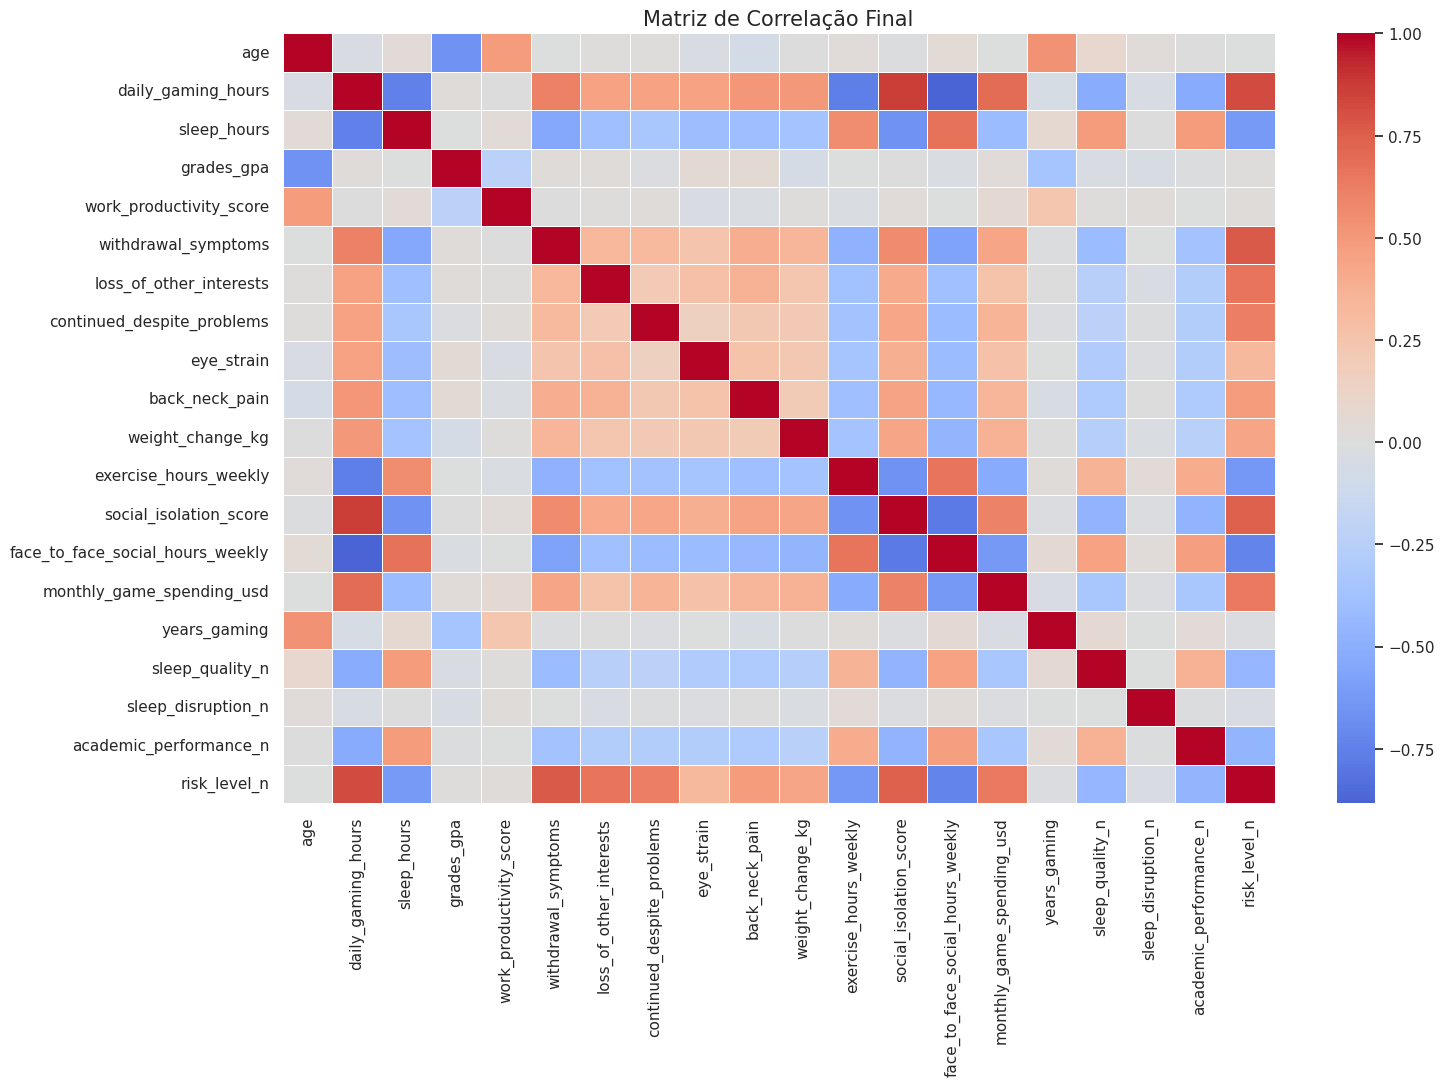


 Ranking de influência no Risco de Vício:
risk_level_n                        1.000000
daily_gaming_hours                  0.816787
withdrawal_symptoms                 0.771706
social_isolation_score              0.744859
loss_of_other_interests             0.665313
monthly_game_spending_usd           0.641454
continued_despite_problems          0.620046
back_neck_pain                      0.487996
weight_change_kg                    0.436139
eye_strain                          0.320830
work_productivity_score             0.014476
grades_gpa                          0.013027
age                                -0.005287
years_gaming                       -0.021864
sleep_disruption_n                 -0.033385
sleep_quality_n                    -0.448265
academic_performance_n             -0.459598
sleep_hours                        -0.613038
exercise_hours_weekly              -0.635993
face_to_face_social_hours_weekly   -0.730541
Name: risk_level_n, dtype: float64


In [110]:
mapa_risco = {'Low': 0, 'Moderate': 1, 'High': 2, 'Severe': 3}

# caso por algum motivo a coluna de risco seja perdida na execução do programa, esse if faz ela ser criada novamente e convertida novamente
# a partir da coluna antiga (vinda do df limpo, mas sem a conversão feita) ou da coluna mais antiga ainda se isso não der certo (vinda do df
# original, antes da limpeza)

if 'risk_level_n' not in df_final.columns:
    if 'gaming_addiction_risk_level' in df_final.columns:
        df_final['risk_level_n'] = df_final['gaming_addiction_risk_level'].map(mapa_risco)
    elif 'gaming_addiction_risk_level' in df.columns:
        df_final['risk_level_n'] = df['gaming_addiction_risk_level'].map(mapa_risco)

if 'risk_level_n' not in df_descritivo.columns:
    if 'gaming_addiction_risk_level' in df_descritivo.columns:
        df_descritivo['risk_level_n'] = df_descritivo['gaming_addiction_risk_level'].map(mapa_risco)
    elif 'gaming_addiction_risk_level' in df.columns:
        df_descritivo['risk_level_n'] = df['gaming_addiction_risk_level'].map(mapa_risco)

# aqui estou filtrando o df mais uma vez para que apenas colunas numéricas passem e garantindo que não haja dados nulos
df_blindado = df_final.select_dtypes(include=[np.number]).fillna(0)

df_blindado = df_blindado.drop(columns=['record_id'], errors='ignore') # --> removendo o ID porque eles não tem sentido nessa pesquisa e eu não
# quero que hajam correlações falsas

# aqui eu começo a gerar a matriz de correlações
plt.figure(figsize=(16, 10))
correlacao = df_blindado.corr() # --> o pandas calcula a relação entre o risco de vício e com todas as colunas aqui

# usei o heatmap para definir tons de azul para correlações negativas, vermelho para positivas e branco para sem correlações
sns.heatmap(correlacao, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlação Final', fontsize=15)
plt.show()

# como a coluna de risco de vício é a que eu mais quero trabalhar, eu listei em ordem decrescente as colunas que mais tem correlação com ela
if 'risk_level_n' in correlacao.columns:
    print("\n Ranking de influência no Risco de Vício:")
    print(correlacao['risk_level_n'].sort_values(ascending=False))
else:
    print("\n Atenção! A coluna de risco ainda não foi encontrada.")

In [111]:
# aqui eu selecionei as colunas mais importantes, ou seja, que tem mais correlação com a coluna de risco de vício porque quero usar somente
# elas daqui pra frente
colunas_selecionadas = [
    'daily_gaming_hours', 'withdrawal_symptoms', 'social_isolation_score',
    'loss_of_other_interests', 'monthly_game_spending_usd', 'continued_despite_problems',
    'back_neck_pain', 'weight_change_kg', 'eye_strain', 'sleep_quality_n',
    'academic_performance_n', 'sleep_hours', 'exercise_hours_weekly',
    'face_to_face_social_hours_weekly', 'risk_level_n'
]

# aqui eu extrai as colunas escolhidas do df anterior e criei um novo df somente com as colunas selecionadas
df_final_enxuto = df_descritivo[colunas_selecionadas].copy()

# só pra checar se o número de colunas variou após a seleção
print(f"Novo DF pronto! Número de colunas atual: {df_final_enxuto.shape[1]}.")
df_final_enxuto.head()

Novo DF pronto! Número de colunas atual: 15.


,daily_gaming_hours,withdrawal_symptoms,social_isolation_score,loss_of_other_interests,monthly_game_spending_usd,continued_despite_problems,back_neck_pain,weight_change_kg,eye_strain,sleep_quality_n,academic_performance_n,sleep_hours,exercise_hours_weekly,face_to_face_social_hours_weekly,risk_level_n
0,0.791045,1,7,0,0.768476,1,0,0.764045,1,0.0,1.0,0.116667,3.7,1.3,3
1,0.186567,0,2,0,0.093235,0,0,0.044944,0,2.0,3.0,0.700000,8.5,10.7,0
2,0.529851,1,5,1,0.201755,1,1,0.202247,0,2.0,0.0,0.233333,7.1,3.2,3
3,0.500000,1,4,1,0.103171,0,1,0.022472,1,2.0,0.0,0.350000,5.2,9.1,2
4,0.470149,1,4,0,0.065048,0,0,0.056180,0,1.0,2.0,0.066667,6.1,4.5,1


In [112]:
# aqui é onde começa o PCA. das 15 colunas, decidi separar em somente duas, x (PC1) e y (PC2). x contém todas as colunas com mais correlação
# com a coluna de risco e y contém a própria coluna de risco

from sklearn.decomposition import PCA

df_final_enxuto = df_final_enxuto.fillna(0) # --> mais uma vez reforçando o filtro de dados nulos

# declaração das novas colunas
X = df_final_enxuto.drop(columns=['risk_level_n'])
y = df_final_enxuto['risk_level_n']

# aqui estou dizendo pro pca a quantidade de colunas que eu quero e ele está criando elas
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(X)

# aqui estou criando uma nova tabela com 3 colunas, as duas criadas pelo PCA e a coluna de risco de vício original
df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])
df_pca['Risco'] = y.reset_index(drop=True) # --> aqui eu estou garantindo que os índices do risco batam certinho com os índices dos
# novos componentes, evitando que os dados fiquem desalinhados

# mostra o quanto de informação que o pca conseguiu manter. é claro que com uma redução enorme como essa, alguns dados vão se perder
print(f"Informação preservada: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Informação preservada: 83.97%


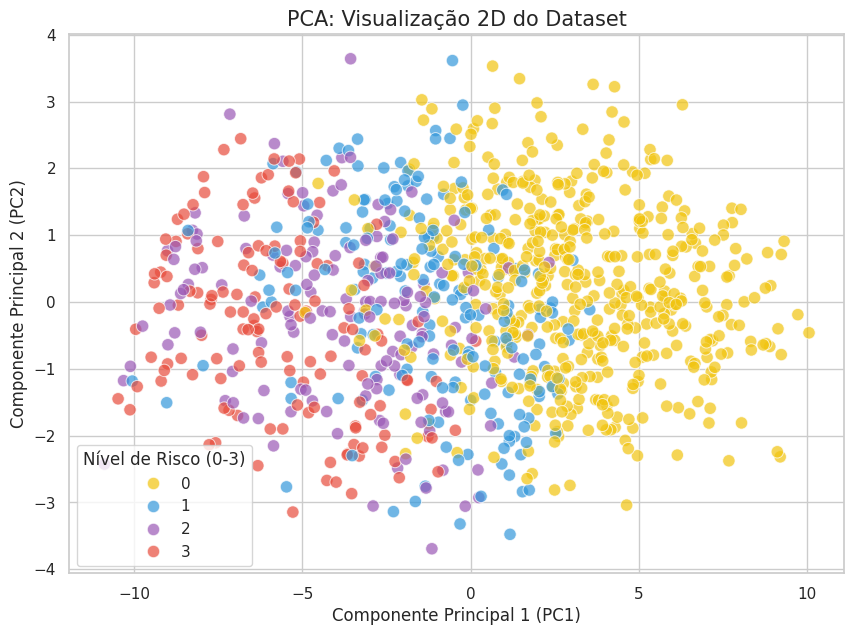

In [113]:
# aqui eu pego o trabalho de pca e crio um scatterplot. o pc1 e o pc2 servem como coordenadas e as cores mudam conforme o nível de risco
# eu deixei as cores com 0.7 (70%) de opacidade porque há muitas sobreposições e eu quero que elas sejam visíveis

plt.figure(figsize=(10, 7))

cores_vibrantes = ['#f1c40f', '#3498db', '#9b59b6', '#e74c3c']

sns.scatterplot(x='PC1', y='PC2', hue='Risco', palette=cores_vibrantes, s=80, data=df_pca, alpha=0.7)

plt.title('PCA: Visualização 2D do Dataset', fontsize=15)
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.legend(title='Nível de Risco (0-3)')
plt.show()

In [114]:
import plotly.express as px

# preparando os dados pro PCA (removendo o 'risk_level_n')
X = df_final_enxuto.drop(columns=['risk_level_n'])

# aplicando o PCA com 3 componentes para o gráfico 3D
pca_3d = PCA(n_components=3)
pca_results_3d = pca_3d.fit_transform(X)

# 3. criando o DataFrame
df_plot_3d = pd.DataFrame(pca_results_3d, columns=['PC1', 'PC2', 'PC3'])

# 4. adicionando a coluna de Risco mapeada com os nomes pra legenda
df_plot_3d['Risco'] = df_final_enxuto['risk_level_n'].map({
    0: '0 - Low',
    1: '1 - Moderate',
    2: '2 - High',
    3: '3 - Severe'
})

# 5. definindo um mapa de cores
mapa_cores= {
    '0 - Low': '#f1c40f',      # Amarelo
    '1 - Moderate': '#3498db', # Azul
    '2 - High': '#9b59b6',     # Roxo
    '3 - Severe': '#e74c3c'    # Vermelho
}

# 6. criando o gráfico interativo com plotly
fig = px.scatter_3d(
    df_plot_3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Risco',
    color_discrete_map= mapa_cores,
    title='PCA 3D: Agrupamento por Nível de Risco (Interativo)',
    labels={'PC1': 'Componente 1', 'PC2': 'Componente 2', 'PC3': 'Componente 3'},
    opacity=0.7
)

# ajustando o tamanho dos pontos
fig.update_traces(marker=dict(size=4))

fig.show()

Para fazer as distribuições de frequência, eu escolhi o meu atributo pricipal (risco de vício), o atributo físico com mais relação com o risco (cansaço visual) e o atributo de hábito com mais relação com o risco (performance acadêmica).

In [115]:
# tabelas do risco de vício

# frequência absoluta (fi)
freq_absoluta = df_final_enxuto['risk_level_n'].value_counts().sort_index() # --> o value_counts conta quantas vezes cada número aparece e o
# sort_index coloca eles em ordem crescente (0, 1, 2, 3)

# frequência relativa (fr)
freq_relativa = df_final_enxuto['risk_level_n'].value_counts(normalize=True).sort_index() # --> o normaliza=True retorna a proporção em relação
# ao total

# tabela de frequências
tabela_frequencia_risco = pd.DataFrame({
    'Frequência Absoluta (fi)': freq_absoluta,
    'Frequência Relativa (fr)': freq_relativa,
    'Frequência Percentual (%)': (freq_relativa * 100).round(2)
})

# renomeando o índice
tabela_frequencia_risco.index = ['0 - Low', '1 - Moderate', '2 - High', '3 - Severe']

print("Tabela de Distribuição de Frequência: Nível de Risco")
display(tabela_frequencia_risco)

print(f"\nTotal de registros (n): {len(df_final_enxuto)}")

Tabela de Distribuição de Frequência: Nível de Risco


,Frequência Absoluta (fi),Frequência Relativa (fr),Frequência Percentual (%)
0 - Low,514,0.517103,51.71
1 - Moderate,188,0.189135,18.91
2 - High,152,0.152918,15.29
3 - Severe,140,0.140845,14.08



Total de registros (n): 994


A tabela de frequência do nível de risco mostra que a maioria dos participantes (51,71%) possui um nível de risco baixo ('Low'). No entanto, há um grupo significativo de cerca de 14% que já se encontra no nível severo ('Severe'), o que indica a existência de uma parcela da amostra com sinais claros de dependência.

In [116]:
# tabelas do cansaço visual

# frequência absoluta (fi)
freq_abs_eye = df_final_enxuto['eye_strain'].value_counts().sort_index()

# frequência relativa (fr)
freq_rel_eye = df_final_enxuto['eye_strain'].value_counts(normalize=True).sort_index()

# tabela de frequências
tabela_eye_strain = pd.DataFrame({
    'Frequência Absoluta (fi)': freq_abs_eye,
    'Frequência Relativa (fr)': freq_rel_eye,
    'Frequência Percentual (%)': (freq_rel_eye * 100).round(2)
})

# renomeando o índice
tabela_eye_strain.index = ['0 - Não apresenta', '1 - Apresenta']

print("Tabela de Distribuição de Frequência: Cansaço Visual (Eye Strain)")
display(tabela_eye_strain)

Tabela de Distribuição de Frequência: Cansaço Visual (Eye Strain)


,Frequência Absoluta (fi),Frequência Relativa (fr),Frequência Percentual (%)
0 - Não apresenta,502,0.50503,50.5
1 - Apresenta,492,0.49497,49.5


A tabela de frequência do cansaço visual mostra uma divisão quase exata na amostra, em que 49,5% dos gamers relatam apresentar cansaço visual e 50,5% que não apresentam. Essa alta incidência de sintomas físicos reforça a relação direta entre o tempo de exposição às telas e os impactos na saúde física dos jogadores.

In [117]:
# tabela da performance acadêmica

# frequência absoluta (fi)
freq_abs_acad = df_final_enxuto['academic_performance_n'].value_counts().sort_index()

# frequência relativa (fr)
freq_rel_acad = df_final_enxuto['academic_performance_n'].value_counts(normalize=True).sort_index()

# tabela de frequências
tabela_performance = pd.DataFrame({
    'Frequência Absoluta (fi)': freq_abs_acad,
    'Frequência Relativa (fr)': freq_rel_acad,
    'Frequência Percentual (%)': (freq_rel_acad * 100).round(2)
})

# renomeando o índice
tabela_performance.index = ['0 - Poor', '1 - Below Average', '2 - Average', '3 - Good', '4 - Excellent']

print("Tabela de Distribuição de Frequência: Performance Acadêmica")
display(tabela_performance)

Tabela de Distribuição de Frequência: Performance Acadêmica


,Frequência Absoluta (fi),Frequência Relativa (fr),Frequência Percentual (%)
0 - Poor,243,0.244467,24.45
1 - Below Average,228,0.229376,22.94
2 - Average,246,0.247485,24.75
3 - Good,174,0.175050,17.51
4 - Excellent,103,0.103622,10.36


A tabela de frequências do desempenho acadêmico mostra que apenas 10,36% dos participantes se autoavaliam como 'Excelentes'. A grande maioria (72,14%) está concentrada nas categorias 'Média', 'Abaixo da Média' ou 'Ruim', sugerindo que o hábito de jogar pode estar impactando as responsabilidades estudantis dos jogadores.

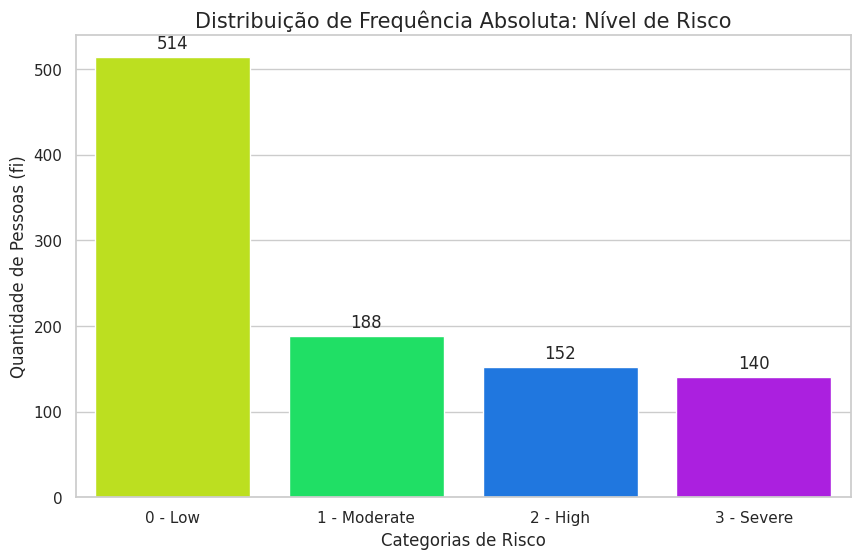

In [118]:
# gráfico em barras do risco de vício

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# criando o gráfico
ax = sns.barplot(x=tabela_frequencia_risco.index,
                 y=tabela_frequencia_risco['Frequência Absoluta (fi)'],
                 hue=tabela_frequencia_risco.index,
                 palette='hsv',
                 legend=False)

# adicionando títulos e rótulos
plt.title('Distribuição de Frequência Absoluta: Nível de Risco', fontsize=15)
plt.xlabel('Categorias de Risco', fontsize=12)
plt.ylabel('Quantidade de Pessoas (fi)', fontsize=12)

# colocando os valores em cima de cada barra (frequência absoluta)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

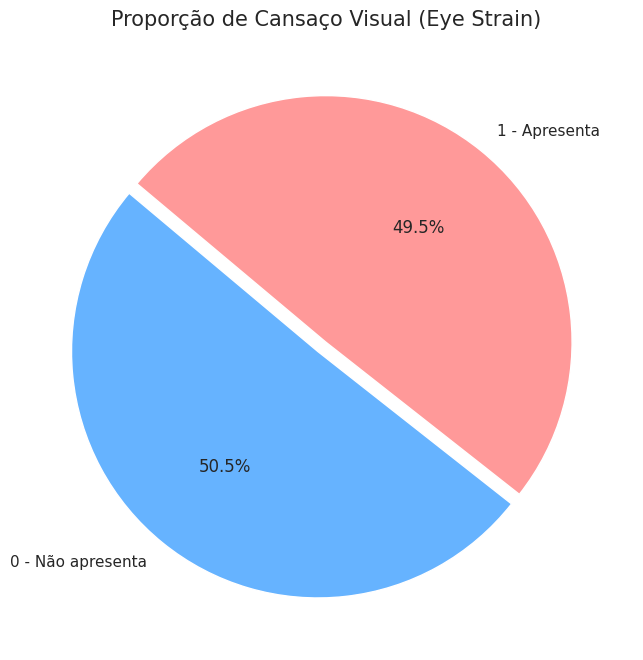

In [119]:
# gráfico do cansaço visual em setores (pizza)

plt.figure(figsize=(8, 8))

# criando o gráfico de pizza
plt.pie(tabela_eye_strain['Frequência Absoluta (fi)'],
        labels=tabela_eye_strain.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['#66b3ff','#ff9999'],
        explode=(0.05, 0)) # dá um leve destaque na fatia

plt.title('Proporção de Cansaço Visual (Eye Strain)', fontsize=15)
plt.show()

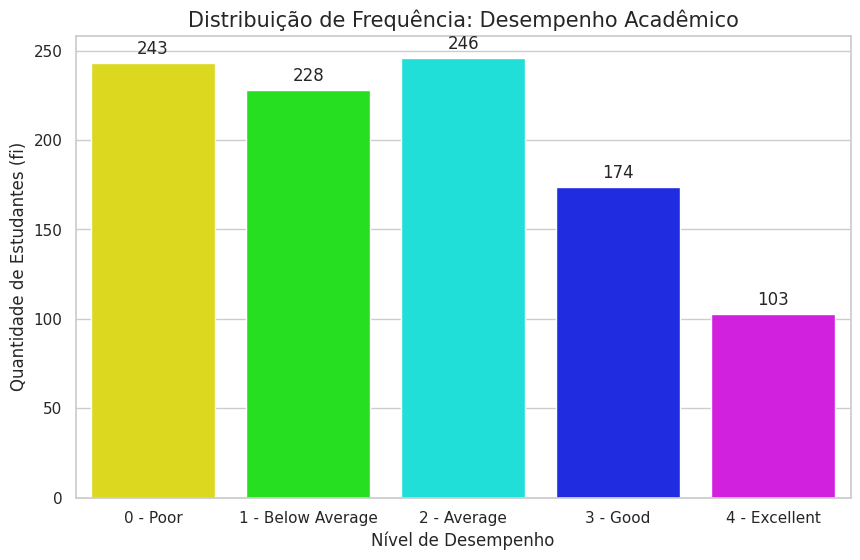

In [120]:
# gráfico da performance acadêmica em barras

plt.figure(figsize=(10, 6))

# criando o gráfico
ax = sns.barplot(x=tabela_performance.index,
                 y=tabela_performance['Frequência Absoluta (fi)'],
                 hue=tabela_performance.index,
                 palette='hsv',
                 legend=False)

# adicionando títulos e rótulos
plt.title('Distribuição de Frequência: Desempenho Acadêmico', fontsize=15)
plt.xlabel('Nível de Desempenho', fontsize=12)
plt.ylabel('Quantidade de Estudantes (fi)', fontsize=12)

# colocando os valores no topo das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

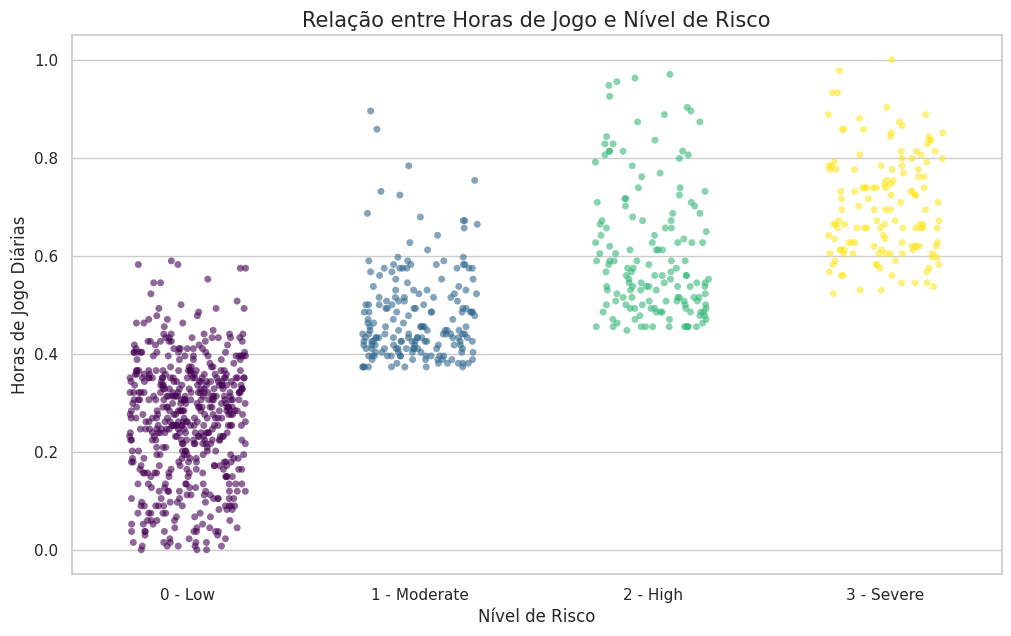

In [121]:
# gráfico da relação entre as horas de jogo diárias e o rsico de vício em dispersão (scatterplot)

plt.figure(figsize=(12, 7))

# criando o gráfico de dispersão com um leve tremor (jitter) pra facilitar a visualização
ax = sns.stripplot(x='risk_level_n',
                   y='daily_gaming_hours',
                   data=df_final_enxuto,
                   hue='risk_level_n',
                   palette='viridis',
                   jitter=0.25,
                   size=5,
                   alpha=0.6,
                   legend=False)

# ajustando os nomes do eixo X para os rótulos corretos
plt.xticks([0, 1, 2, 3], ['0 - Low', '1 - Moderate', '2 - High', '3 - Severe'])

# adicionando títulos e rótulos
plt.title('Relação entre Horas de Jogo e Nível de Risco', fontsize=15)
plt.xlabel('Nível de Risco', fontsize=12)
plt.ylabel('Horas de Jogo Diárias', fontsize=12)

plt.show()

Medidas de Resumo:

Começando pelas medidas de tendência central, eu escolhi o atributo daily_hours_gaming, ou seja, a quantidade de horas em jogo diária, porque diferente do atributo de risco de vício, que apesar de ter valores numéricos, eles são qualitativos, o atributo das horas de jogo tem valores quantitativos, perfeito para média, mediana, etc.

In [122]:
df_descritivo = df[df['daily_gaming_hours'] <= limite_superior].copy()

df_descritivo.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level,gender_n,mood_state_n,risk_level_n
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,6.8,3.7,7,1.3,383.70,3,Severe,1,1,3
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,0.4,8.5,2,10.7,46.64,1,Low,1,5,0
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,1.8,7.1,5,3.2,100.81,6,Severe,1,5,3
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,0.2,5.2,4,9.1,51.60,7,High,0,8,2
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,0.5,6.1,4,4.5,32.57,1,Moderate,1,0,1


In [123]:
# medidas de Tendência Central do atributo daily_hours_gaming
# o pandas tem funções próprias pra calcular média, moda, etc

# média:
media_gaming = df_final_enxuto['daily_gaming_hours'].mean()

# mediana:
mediana_gaming = df_final_enxuto['daily_gaming_hours'].median()

# moda:
# pegamos o primeiro valor [0] do resultado
moda_gaming = df_final_enxuto['daily_gaming_hours'].mode()[0]

# criando uma tabela com o resumo dos r
tabela_central_gaming = pd.DataFrame({
    'Medida de Tendência Central ||': ['Média', 'Mediana', 'Moda'],
    'Resultado (daily_gaming_hours)': [media_gaming, mediana_gaming, moda_gaming]
}).round(2)

print(tabela_central_gaming.to_string(index=False))

Medida de Tendência Central ||  Resultado (daily_gaming_hours)
                         Média                            0.42
                       Mediana                            0.40
                          Moda                            0.40


Decidi também calcular a moda dos dados qualitativos principais escolhidos anteriormente, como o risco de vício.

In [124]:
mapa_risco_vicio = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Severe'}
mapa_performance_academica = {0: 'Poor', 1: 'Below Average', 2: 'Average', 3: 'Good', 4: 'Excellent'}
mapa_cansaco_visual = {0: 'Não apresenta', 1: 'Apresenta'}

moda_risco_vicio = df_final_enxuto['risk_level_n'].mode()[0]
moda_performance_academica = df_final_enxuto['academic_performance_n'].mode()[0]
moda_cansaco_visual = df_final_enxuto['eye_strain'].mode()[0]

# criando o df apenas com as modas
tabela_modas_qualitativas = pd.DataFrame({
    'Atributo Qualitativo': [
        'Risco de Vício (Moda)',
        'Performance Acadêmica (Moda)',
        'Cansaço Visual (Moda)'
    ],
    'Valor Mais Frequente': [
        moda_risco_vicio,
        moda_performance_academica,
        moda_cansaco_visual
    ],
    'Categoria': [
        mapa_risco_vicio[moda_risco_vicio],
        mapa_performance_academica[moda_performance_academica],
        mapa_cansaco_visual[moda_cansaco_visual]
    ]
})


print(tabela_modas_qualitativas.to_string(index=False))

        Atributo Qualitativo  Valor Mais Frequente     Categoria
       Risco de Vício (Moda)                   0.0           Low
Performance Acadêmica (Moda)                   2.0       Average
       Cansaço Visual (Moda)                   0.0 Não apresenta


Para calcular as medidas de dispersão do atributo daily_gaming_hours, usei algumas funções inclusas no numpy.

In [125]:
df_final_enxuto = df_descritivo

# medidas de dispersão

# variância:

variancia_gaming = df_final_enxuto['daily_gaming_hours'].var()

# desvio padrão:

desvio_padrao_gaming = df_final_enxuto['daily_gaming_hours'].std()

# coeficiente de variação:

media_gaming = df_final_enxuto['daily_gaming_hours'].mean()
coeficiente_variacao_gaming = (desvio_padrao_gaming / media_gaming) * 100

print(f"Variância: {variancia_gaming:.2f}")
print(f"Desvio Padrão: {desvio_padrao_gaming:.2f}")
print(f"Coeficiente de Variação: {coeficiente_variacao_gaming:.2f}%")
print(f"\n")

tabela_dispersao_gaming = pd.DataFrame({
    'Medida de Dispersão': ['Variância', 'Desvio Padrão', 'Coeficiente de Variação (%)'],
    'Resultado (daily_gaming_hours)': [variancia_gaming, desvio_padrao_gaming, coeficiente_variacao_gaming]
}).round(2)


desvio_padrao_gaming = df_final_enxuto['daily_gaming_hours'].head()

Variância: 7.83
Desvio Padrão: 2.80
Coeficiente de Variação: 45.87%




In [126]:
import pandas as pd

# carregando o df original
df = pd.read_csv('Gaming and Mental Health.csv')

# calculando os quartis de 25%, 50% (mediana) e 75%
q1_gh = df['daily_gaming_hours'].quantile(0.25)
q2_gh = df['daily_gaming_hours'].median()
q3_gh = df['daily_gaming_hours'].quantile(0.75)

# calculando o intervalo interquartílico (iqr)
iqr_gh = q3_gh - q1_gh

tabela_posicao_relativa = pd.DataFrame({
    'Medida de Posição': ['1º Quartil (Q1)', '2º Quartil (Mediana)', '3º Quartil (Q3)', 'IQR'],
    'Valor (daily_gaming_hours)': [q1_gh, q2_gh, q3_gh, iqr_gh]
}).round(2)

display(tabela_posicao_relativa.style.hide(axis='index'))

Medida de Posição,Valor (daily_gaming_hours)
1º Quartil (Q1),4.100000
2º Quartil (Mediana),6.000000
3º Quartil (Q3),8.020000
IQR,3.930000


Ao analisar o primeiro quartil, percebemos que 25% da minha amostra é composta por jogadores que dedicam até 4,10 horas por dia, o que representa o grupo com hábitos mais moderados. Já o segundo quartil, que é a mediana, mostrou que metade dos estudantes joga até 6 horas. Por fim, o terceiro quartil revelou que 75% dos participantes jogam até 8,03 horas diárias, o que me permitiu concluir que apenas a parcela final de 25% dos alunos é que realmente ultrapassa essa marca e entra na zona de uso mais intenso.

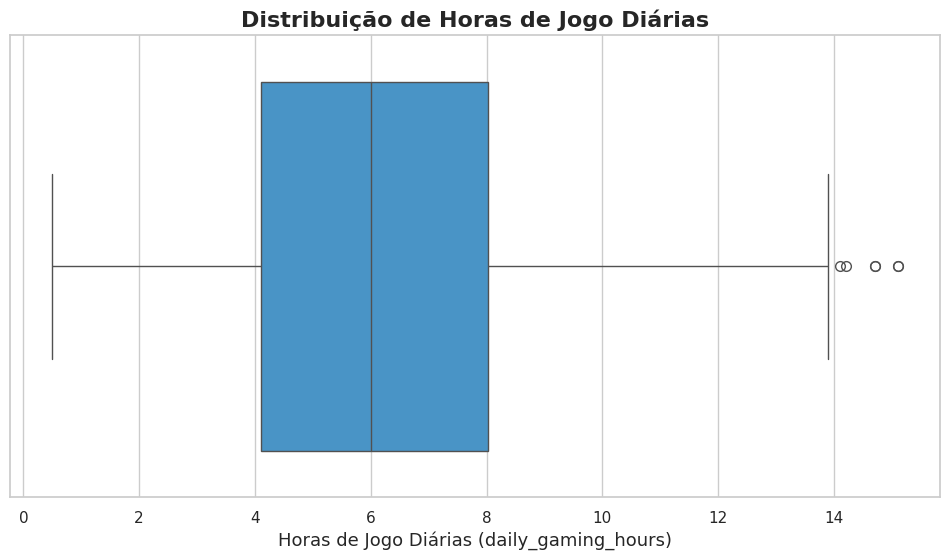

In [127]:
# boxplot das medidas de posição relativas calculadas

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

# x define a variável que vamos plotar
# color define a cor da caixa
sns.boxplot(x=df['daily_gaming_hours'], color='#3498db', fliersize=7)

plt.title('Distribuição de Horas de Jogo Diárias', fontsize=16, fontweight='bold')
plt.xlabel('Horas de Jogo Diárias (daily_gaming_hours)', fontsize=13)

plt.show()

Eu já tinha feito um pouco dessa parte de medida de posição relatiba usando o comando describe, mas percebi que ela não estava completa porque faltava a variância, o coeficiente de variância e a moda. Por isso, decidi refazer os cálculos para adicionar esses novos dados e entender melhor como as horas de jogo se distribuem. Com esses novos resultados, consegui ver que 50% dos alunos jogam entre 4 e 8 horas por dia, e usei o IQR para entender a variação desse grupo central e identificar quem são os jogadores com hábitos mais extremos.


Medidas de Associação:

In [128]:
correlacao_pearson = df_final_enxuto['daily_gaming_hours'].corr(df_final_enxuto['risk_level_n'])

print(f"Coeficiente de Correlação de Pearson: {correlacao_pearson:.2f}")

Coeficiente de Correlação de Pearson: 0.82


/tmp/ipykernel_4542/3582750968.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




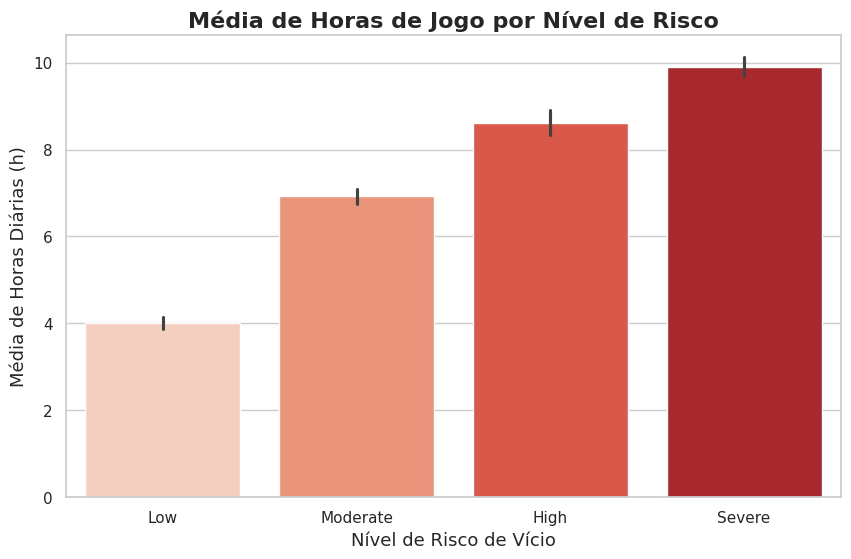

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

ordem_risco = ['Low', 'Moderate', 'High', 'Severe']

plt.figure(figsize=(10, 6))

sns.barplot(data=df_final_enxuto,
            x='gaming_addiction_risk_level',
            y='daily_gaming_hours',
            order=ordem_risco,
            palette='Reds')

plt.title('Média de Horas de Jogo por Nível de Risco', fontsize=16, fontweight='bold')
plt.xlabel('Nível de Risco de Vício', fontsize=13)
plt.ylabel('Média de Horas Diárias (h)', fontsize=13)

plt.show()

Eu já tinha a lógica dessa correlação quando montei o meu mapa de calor lá atrás, mas agora eu extraí o valor numérico exato (o tal coeficiente de Pearson). Como eu já tinha a coluna de risco em formato numérico no meu dataframe enxuto, eu só precisei calcular a relação direta entre ela e as horas de jogo. Encontrei um resultado de 0,82, o que prova que existe uma correlação positiva muito forte, ou seja, ficou claro que quanto mais horas o jogador passa jogando, maior acaba sendo o seu nível de risco de vício.

Implementação do KMeans e do GMM:

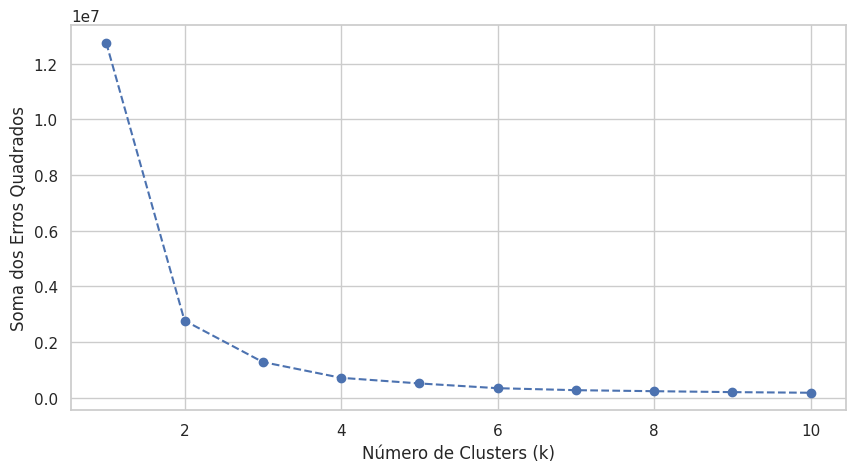

Análise completa!


In [130]:
# eu criei um df novo apenas com dados numéricos, porque o programa estava
# detectando dados nulos e em textos com o df que eu estava usando antes

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# filtrando
df_numerico = df_final_enxuto.select_dtypes(include=['number']).dropna()

# aplicando a soma dos erros quadrados
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_numerico)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), sse, marker='o', linestyle='--')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Soma dos Erros Quadrados')
plt.show()

print("Análise completa!")

In [131]:
# como a 'ponta do cotovelo' acontece em k = 3, vamos utilizar 3 clusters então
n_clusters_escolhido = 3

kmeans = KMeans(n_clusters=n_clusters_escolhido, random_state=42, n_init=10)
gmm = GaussianMixture(n_components=n_clusters_escolhido, random_state=42)

# criando as colunas no df_numerico
df_numerico['cluster_kmeans'] = kmeans.fit_predict(df_numerico)
df_numerico['cluster_gmm'] = gmm.fit_predict(df_numerico)

# analisando a média de cada grupo
analise_kmeans = df_numerico.groupby('cluster_kmeans').mean()
display(analise_kmeans)

analise_gmm = df_numerico.groupby('cluster_gmm').mean()
display(analise_gmm)

,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gender_n,mood_state_n,risk_level_n,cluster_gmm
cluster_kmeans,,,,,,,,,,,,,,,
0,20.478125,7.126875,5.249688,1.871313,3.737500,1.702500,6.445000,4.450000,6.540313,127.736969,5.956250,0.662500,3.637500,1.203125,2.0
1,20.427273,10.289091,4.600909,2.011909,4.136364,2.631818,4.930000,6.554545,2.588182,384.868091,5.272727,0.781818,3.681818,2.536364,1.0
2,20.464539,4.700532,6.252837,1.896135,3.485816,1.177128,7.668262,2.959220,9.356206,36.055816,5.776596,0.687943,4.015957,0.439716,0.0


,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gender_n,mood_state_n,risk_level_n,cluster_kmeans
cluster_gmm,,,,,,,,,,,,,,,
0,20.464539,4.700532,6.252837,1.896135,3.485816,1.177128,7.668262,2.959220,9.356206,36.055816,5.776596,0.687943,4.015957,0.439716,2.0
1,20.427273,10.289091,4.600909,2.011909,4.136364,2.631818,4.930000,6.554545,2.588182,384.868091,5.272727,0.781818,3.681818,2.536364,1.0
2,20.478125,7.126875,5.249688,1.871313,3.737500,1.702500,6.445000,4.450000,6.540313,127.736969,5.956250,0.662500,3.637500,1.203125,0.0


Eu utilizei o k-Means e o GMM para segmentar as pessoas em três perfis distintos, o que me permitiu observar como o comportamento de jogo escala conforme o risco aumenta. O primeiro grupo é formado por jogadores casuais, que mantêm uma média baixa de 3,5 horas diárias e apresentam o menor índice de vulnerabilidade. O segundo grupo representa os jogadores regulares, com uma média de 7 horas, onde o risco já começa a subir para um nível moderado. Por fim, o terceiro grupo é o de pessoas que jogam em média mais de 11 horas por dia, ou seja, os que apresentam os maiores níveis de risco de vício.

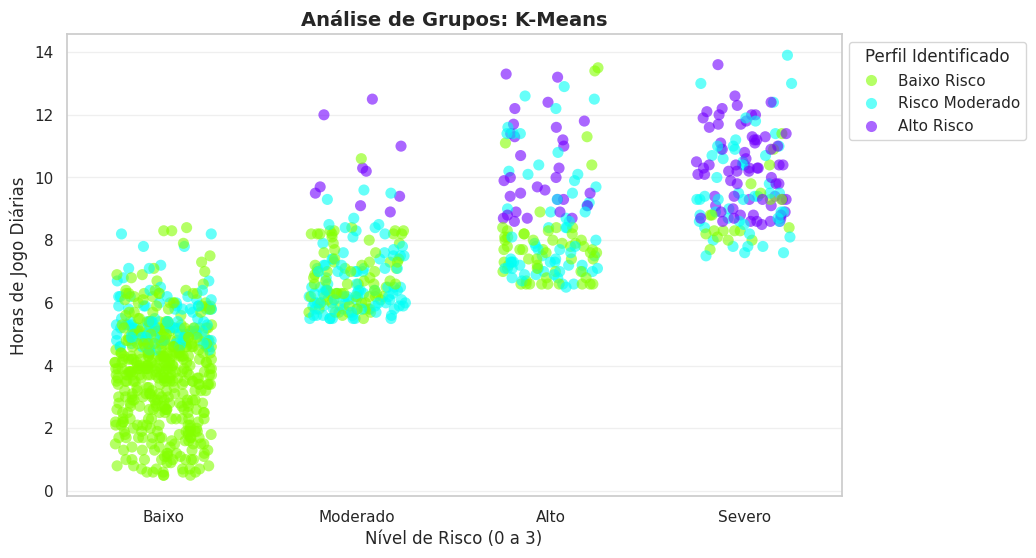

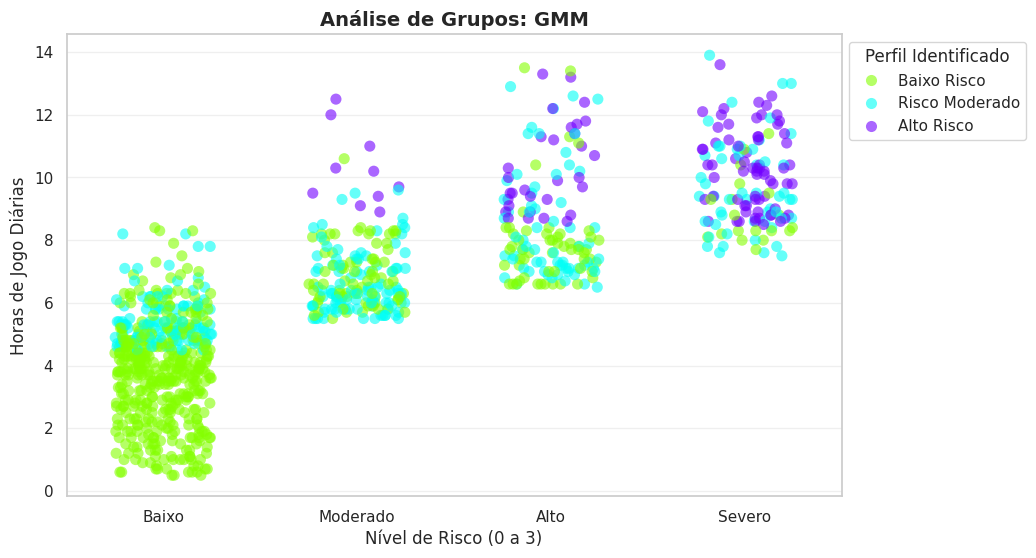

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# agrupando pela média de horas de cada cluster
ordem_kmeans = df_numerico.groupby('cluster_kmeans')['daily_gaming_hours'].mean().sort_values().index
ordem_gmm = df_numerico.groupby('cluster_gmm')['daily_gaming_hours'].mean().sort_values().index

# criando o mapeamento dinâmico
map_kmeans = {ordem_kmeans[0]: 'Baixo Risco', ordem_kmeans[1]: 'Risco Moderado', ordem_kmeans[2]: 'Alto Risco'}
map_gmm = {ordem_gmm[0]: 'Baixo Risco', ordem_gmm[1]: 'Risco Moderado', ordem_gmm[2]: 'Alto Risco'}

df_numerico['Perfil K-Means'] = df_numerico['cluster_kmeans'].map(map_kmeans)
df_numerico['Perfil GMM'] = df_numerico['cluster_gmm'].map(map_gmm)

# gráfico do k-means
plt.figure(figsize=(10, 6))
sns.stripplot(data=df_numerico, x='risk_level_n', y='daily_gaming_hours',
              hue='Perfil K-Means',
              hue_order=['Baixo Risco', 'Risco Moderado', 'Alto Risco'],
              palette='hsv', jitter=0.25, size=8, alpha=0.6)

plt.title('Análise de Grupos: K-Means', fontsize=14, fontweight='bold')
plt.xlabel('Nível de Risco (0 a 3)', fontsize=12)
plt.ylabel('Horas de Jogo Diárias', fontsize=12)
plt.xticks([0, 1, 2, 3], ['Baixo', 'Moderado', 'Alto', 'Severo'])
plt.legend(title='Perfil Identificado', bbox_to_anchor=(1, 1))
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# gráfico do gmm
plt.figure(figsize=(10, 6))
sns.stripplot(data=df_numerico, x='risk_level_n', y='daily_gaming_hours',
              hue='Perfil GMM',
              hue_order=['Baixo Risco', 'Risco Moderado', 'Alto Risco'],
              palette='hsv', jitter=0.25, size=8, alpha=0.6)

plt.title('Análise de Grupos: GMM', fontsize=14, fontweight='bold')
plt.xlabel('Nível de Risco (0 a 3)', fontsize=12)
plt.ylabel('Horas de Jogo Diárias', fontsize=12)
plt.xticks([0, 1, 2, 3], ['Baixo', 'Moderado', 'Alto', 'Severo'])
plt.legend(title='Perfil Identificado', bbox_to_anchor=(1, 1))
plt.grid(True, axis='y', alpha=0.3)
plt.show()

Conclusão: Com base nas análises realizadas, este projeto demonstrou que o tempo dedicado aos video games é o principal fator determinante para o risco de vício entre os jogadores. Através da aplicação dos algoritmos k-Means e GMM, foi possível segmentar os perfis comportamentais de forma que revelase que o grupo de alto risco apresenta uma carga horária média superior a 11 horas diárias, enquanto os jogadores de baixo risco mantêm uma média de apenas 3,5 horas. A forte correlação matemática de 0,82 validou que essa associação não é a toa, pois confirma a necessidade de monitoramento do equilíbrio entre estudos, trabalho e lazer para a preservação da saúde mental.

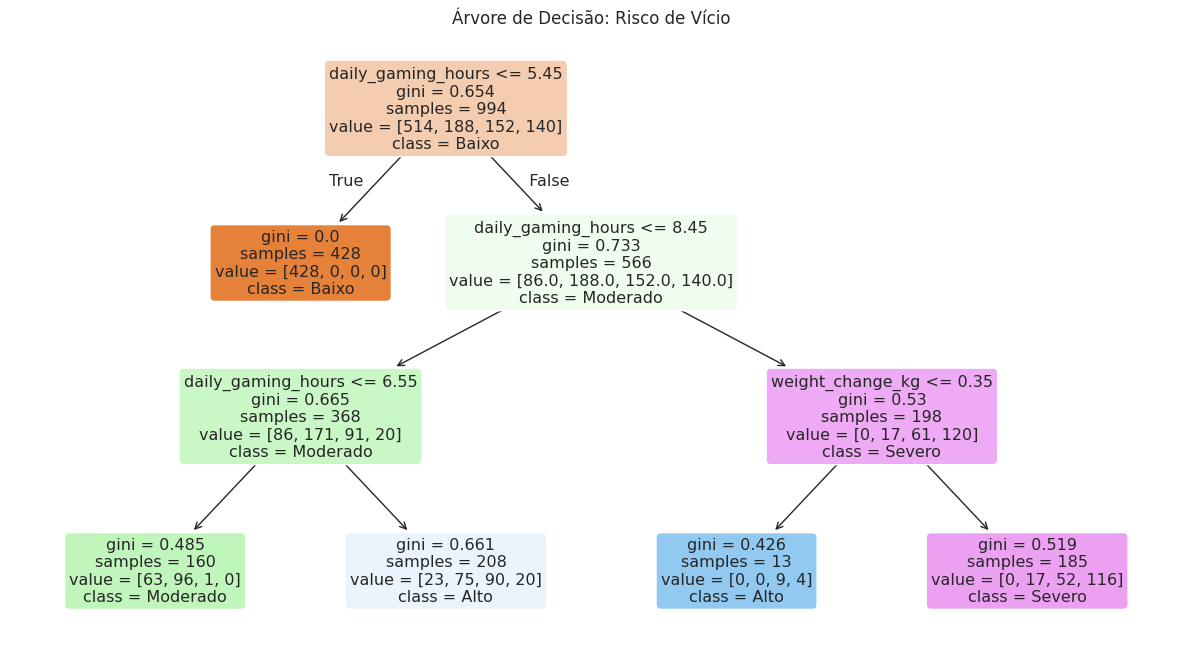

Colunas mais importantes para a decisão:
daily_gaming_hours    0.989802
weight_change_kg      0.010198
age                   0.000000
dtype: float64


In [136]:
# aqui começa a árvore de decisões do meu projeto. eu decidi prever a coluna
# "gaming_addiction_risk_level" já que ela tem sido a principal no meu projeto

# importando o necessário pra criar uma árvore de decisões
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# aqui eu tive que dropar algumas colunas de texto que eu criei anteriormente
# pra deixar o k-means e o gmm maiis bonitinhos
# o x é quem ajuda a prever e y é o que queremos prever
colunas_para_remover = ['risk_level_n', 'Perfil K-Means', 'Perfil GMM', 'Perfil Real']
X = df_numerico.drop(columns=[col for col in colunas_para_remover if col in df_numerico.columns], errors='ignore')
y = df_numerico['risk_level_n']

# treinando a árvore (max_depth=3 para a árvore não ficar gigante e ser fácil de explicar no slide)
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

# gráfico da árvore
plt.figure(figsize=(15, 8))
plot_tree(clf,
          feature_names=X.columns,
          class_names=['Baixo', 'Moderado', 'Alto', 'Severo'],
          filled=True,
          rounded=True)

plt.title("Árvore de Decisão: Risco de Vício")
plt.show()

# mostrando o que é mais importante para a árvore
importancia = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Colunas mais importantes para a decisão:")
print(importancia.head(3))

A aplicação do modelo de árvore de decisão permitiu extrair as regras lógicas que ditam o risco de vício no dataset, demonstrando uma excelente capacidade de generalização ao identificar padrões claros nos registros históricos. Através do processo de indução, o algoritmo revelou que a variável de maior importância para a classificação é o tempo de jogo diário, estabelecendo que pessoas com carga horária inferior a 5,45 horas pertencem predominantemente à categoria de baixo risco. Na classe Moderado, ficaram as pessoas que jogam mais que 5,45 horas e menos ou igual a 6.55 horas. Para os casos de exposição mais elevada, o modelo passou a utilizar atributos secundários, como a alteração de peso, para discriminar entre os níveis de risco alto e severo. Essa estrutura prova que o vício não é determinado apenas pelo tempo de tela, mas também por marcadores biológicos que refletem o impacto físico do comportamento sedentário, validando a eficácia do uso de múltiplas características para separar exemplos de classes distintas com precisão.

In [134]:
df_final_enxuto.to_csv('gaming_mental_health_clean.csv', index=False) # --> aqui eu transformei o df finalizado em um arquivo csv
# index=False --> eu também pedi pro pandas não criar uma coluna nova com o número de linhas caso o aquivo seja aberto no excel, por exemplo,
# pra deixar tudo mais limpo

print("Arquivo 'gaming_mental_health_clean.csv' salvo com sucesso!")

# salvando o arquivo no google colab e baixando ele na máquina
from google.colab import files
files.download('gaming_mental_health_clean.csv')

Arquivo 'gaming_mental_health_clean.csv' salvo com sucesso!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>